In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (8,5)

In [8]:
df = pd.read_csv("energy_efficiency.csv")
attributes = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1']

In [9]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

outliers = {}
for col in attributes:
    outliers[col] = detect_outliers(df[col])
    print(f"{col}: {len(outliers[col])} outliers")
    print(outliers[col].values)


X1: 0 outliers
[]
X2: 76 outliers
[  69.23406592 1249.60355917 1329.0524558     3.09855791   82.38088555
 1244.15181003  102.98022526  121.97035208   80.33599771 1256.36540623
 1237.28001385  110.09476557 1270.26575557    4.91874527 1318.72511658
  128.41958332 1233.72891218 1271.73095804 1303.0162977  1312.07365651
   67.4192593  1299.51218857  132.1624705  1276.51545595    3.39474515
 1317.66273723 1325.01981705   52.01659577 1313.89992751 1272.03642779
 1215.83852595 1346.55887338 1237.86981674  118.01779305 1257.40651205
 1238.00590639  130.11011328  127.47929162   41.65387168 1298.3460388
 1309.7539866    48.62153485   13.13546912 1267.74655668 1300.13295073
  104.05979848 1313.98569947   80.35894613  123.17677238 1289.67837715
 1284.89484369   28.63173794 1217.85863044  112.21930369   43.38222648
   18.56119188   67.2272572    86.30586748 1272.0734025  1302.46424219
   30.89345871 1325.66816383 1216.77757398   88.81491345 1255.4749953
   45.1452475    92.57001126 1238.03727973  1

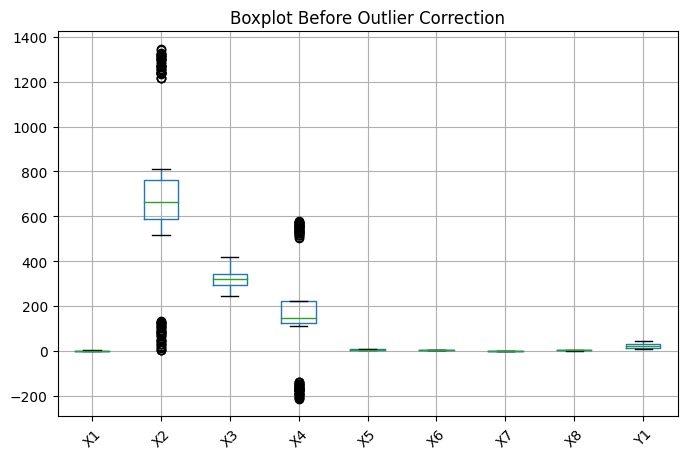

In [10]:
df[attributes].boxplot(rot=45)
plt.title('Boxplot Before Outlier Correction')
plt.show()

In [15]:
df_corrected = df.copy()
for col in attributes:
    median = df[col].median()
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_corrected.loc[(df_corrected[col] < lower) | (df_corrected[col] > upper), col] = median

df_corrected.to_csv('energy_efficiency_corrected.csv', index=False)

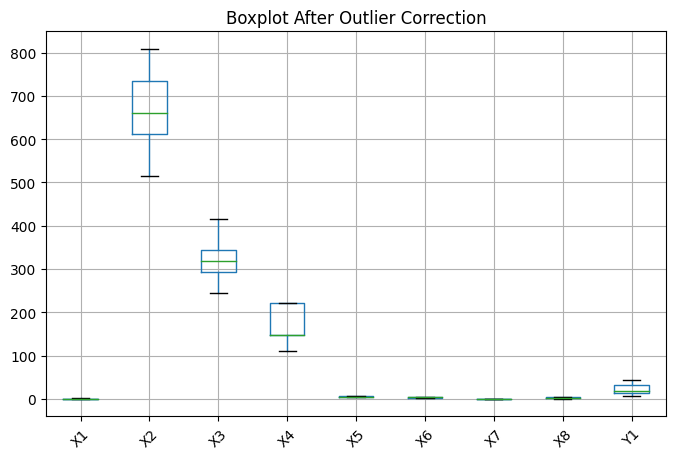

In [16]:
df_corrected[attributes].boxplot(rot=45)
plt.title('Boxplot After Outlier Correction')
plt.show()

In [19]:
df_corrected=pd.read_csv("energy_efficiency_corrected.csv")

In [20]:
pearson_corr = df_corrected[attributes].corr(method='pearson')
spearman_corr = df_corrected[attributes].corr(method='spearman')

pearson_corr, spearman_corr

(              X1        X2            X3        X4            X5  \
 X1  1.000000e+00 -0.942497 -2.037817e-01 -0.800037  8.277473e-01   
 X2 -9.424973e-01  1.000000  1.750921e-01  0.777158 -8.140754e-01   
 X3 -2.037817e-01  0.175092  1.000000e+00 -0.266758  2.809757e-01   
 X4 -8.000365e-01  0.777158 -2.667583e-01  1.000000 -8.929314e-01   
 X5  8.277473e-01 -0.814075  2.809757e-01 -0.892931  1.000000e+00   
 X6  4.678592e-17 -0.005123 -2.429499e-17 -0.011894  4.492205e-17   
 X7 -2.960552e-15  0.001291 -8.567455e-17 -0.043467  1.489134e-17   
 X8 -7.107006e-16  0.007637  2.067384e-16 -0.001131 -2.920613e-17   
 Y1  6.222722e-01 -0.625556  4.556712e-01 -0.797556  8.894307e-01   
 
               X6            X7            X8        Y1  
 X1  4.678592e-17 -2.960552e-15 -7.107006e-16  0.622272  
 X2 -5.122874e-03  1.290630e-03  7.636979e-03 -0.625556  
 X3 -2.429499e-17 -8.567455e-17  2.067384e-16  0.455671  
 X4 -1.189358e-02 -4.346669e-02 -1.131170e-03 -0.797556  
 X5  4.492205e-17 

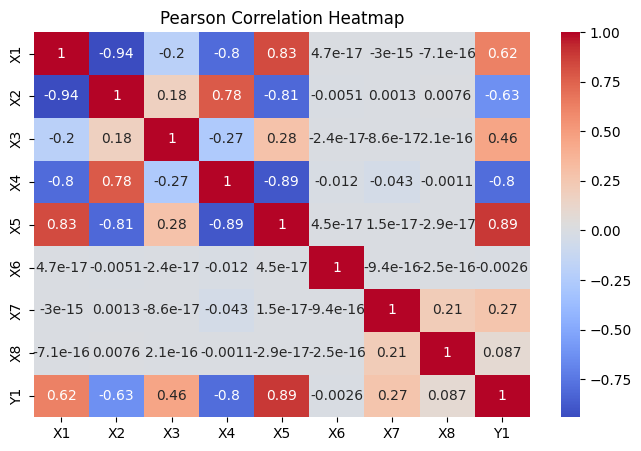

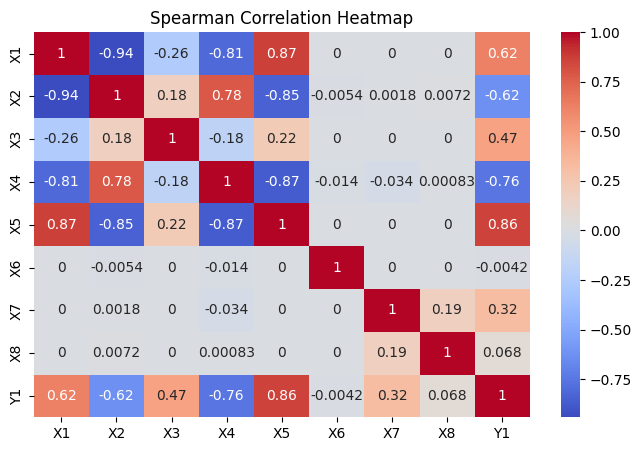

In [21]:
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title('Pearson Correlation Heatmap')
plt.show()

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm')
plt.title('Spearman Correlation Heatmap')
plt.show()

In [22]:
target = 'Y2'
attributes_1 = attributes.copy()
attributes_1.append(target)

pearson = df_corrected[attributes_1].corr(method='pearson')[target]
spearman = df_corrected[attributes_1].corr(method='spearman')[target]

pd.DataFrame({

    'Pearson': pearson,

    'Spearman': spearman
})

,Pearson,Spearman
X1,0.634339,0.651019
X2,-0.637969,-0.646669
X3,0.427117,0.415991
X4,-0.798415,-0.761092
X5,0.895785,0.864876
X6,0.014290,0.017606
X7,0.207505,0.288904
X8,0.050525,0.046477
Y1,0.975862,0.972689
Y2,1.000000,1.000000


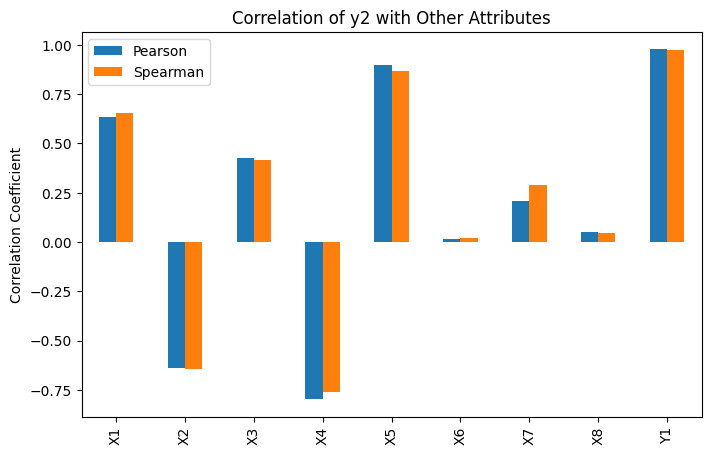

In [23]:
pd.DataFrame({
    'Pearson': pearson,
    'Spearman': spearman
}).drop(target).plot(kind='bar')
plt.title('Correlation of y2 with Other Attributes')
plt.ylabel('Correlation Coefficient')
plt.show()

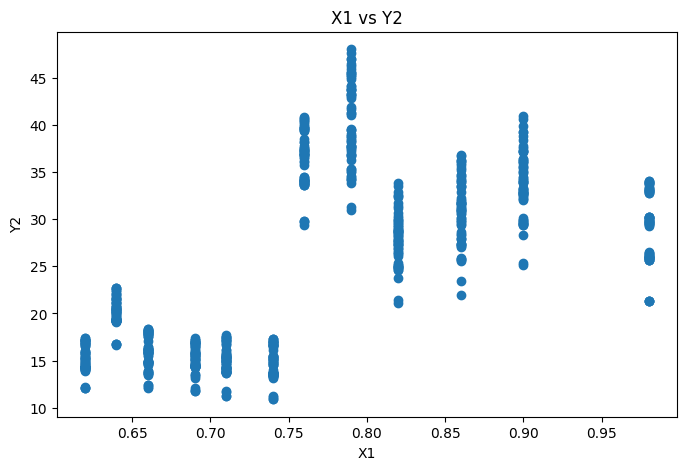

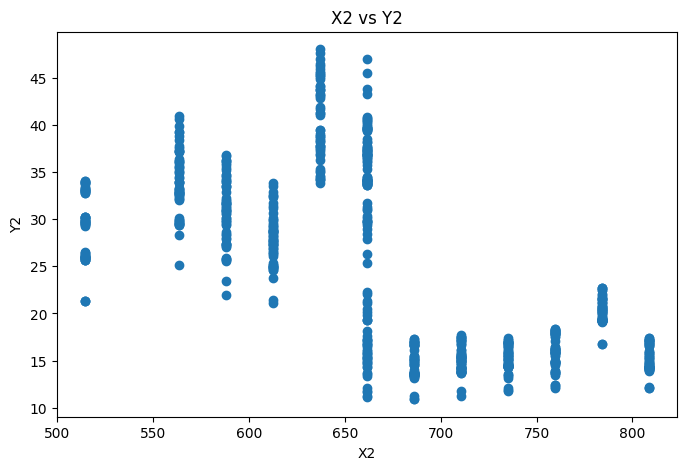

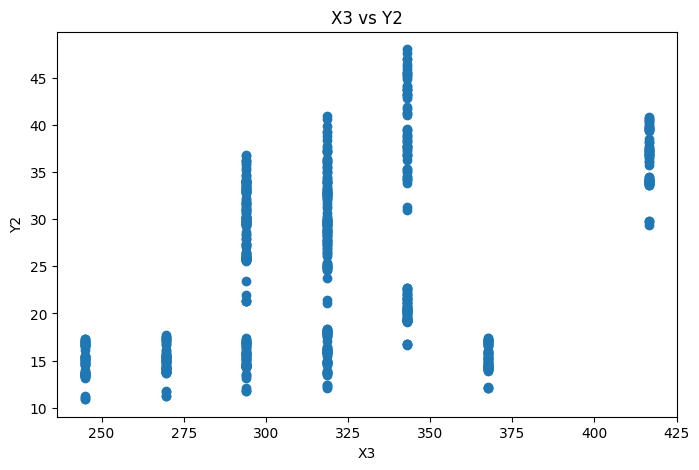

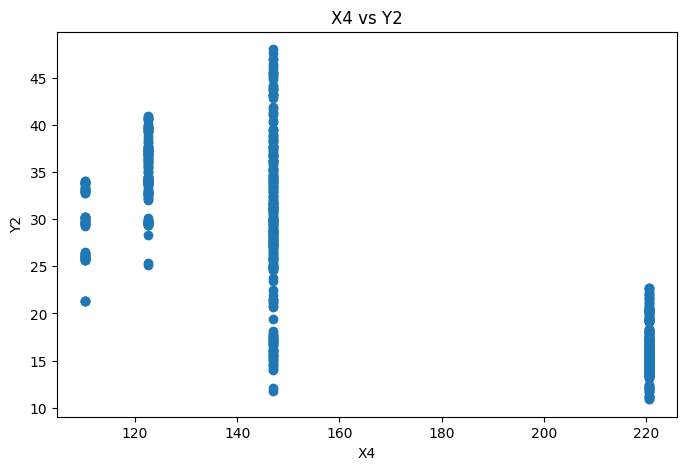

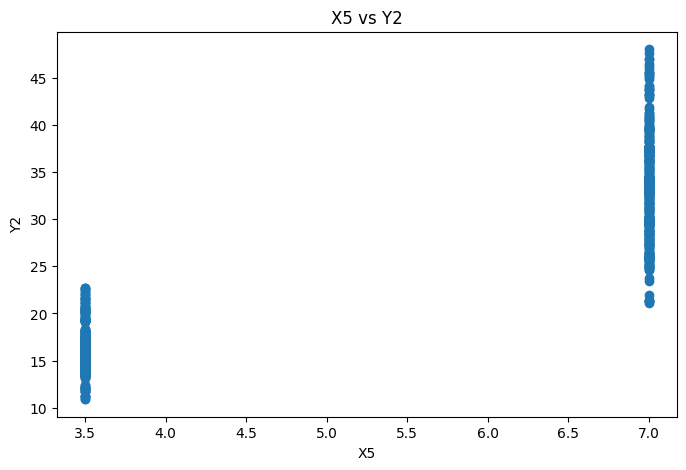

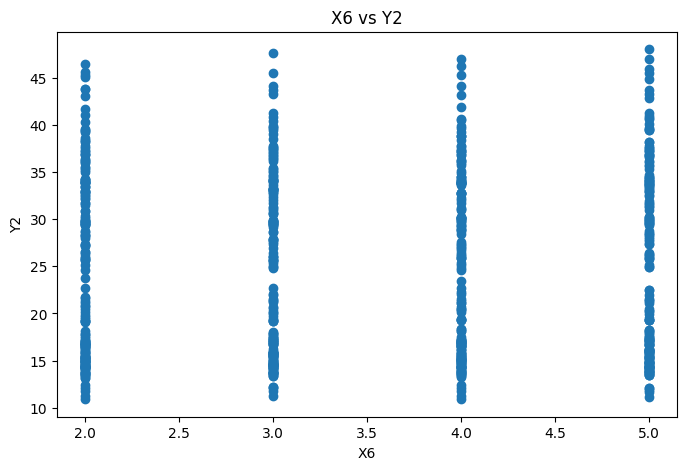

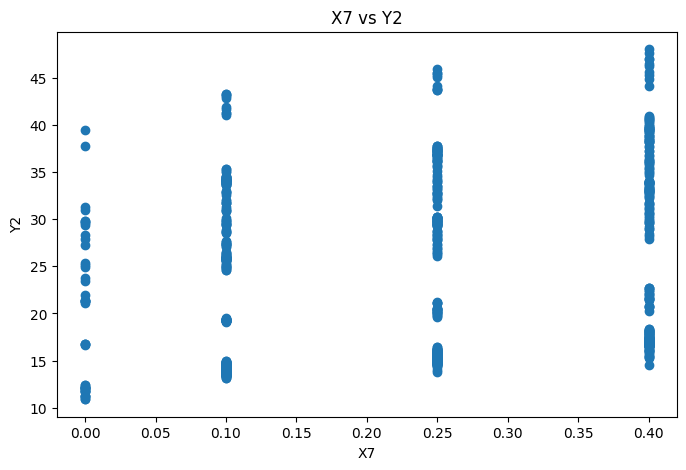

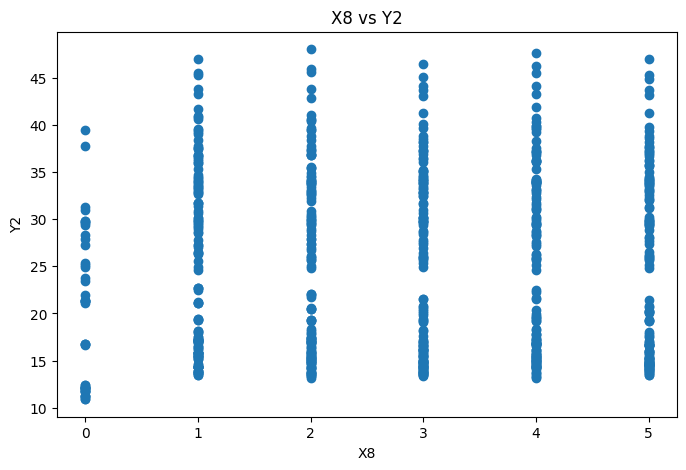

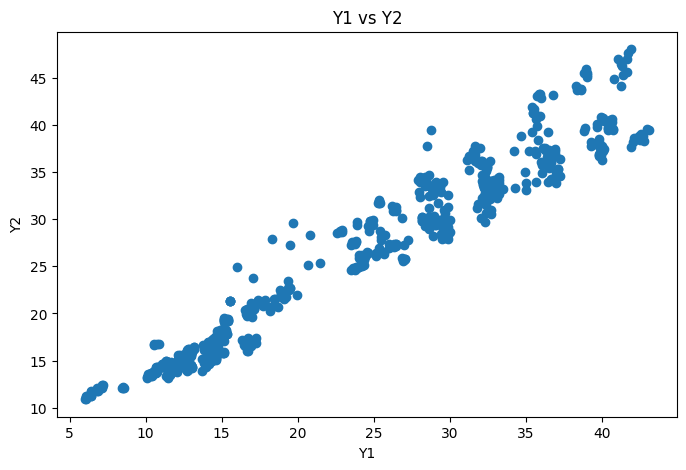

In [24]:
for col in attributes:
    if col != target:
        plt.scatter(df_corrected[col], df_corrected[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f'{col} vs {target}')
        plt.show()

In [26]:
df_corrected[attributes].agg(['min','max'])

,X1,X2,X3,X4,X5,X6,X7,X8,Y1
min,0.62,514.5,245.0,110.25,3.5,2.0,0.0,0,6.01
max,0.98,808.5,416.5,220.50,7.0,5.0,0.4,5,43.10


In [35]:
scaler_01 = MinMaxScaler(feature_range=(0,1))
norm_01 = scaler_01.fit_transform(df_corrected[attributes])

In [36]:
df_norm_01 = pd.DataFrame(
    norm_01,
    columns=attributes,
    index=df_corrected.index
)
df_norm_01.to_csv("energy_efficiency_normalisation.csv", index=False)


In [37]:
scaler_030 = MinMaxScaler(feature_range=(10,30))
norm_030 = scaler_030.fit_transform(df_corrected[attributes])

In [38]:

df_norm_030 = pd.DataFrame(
    norm_030,
    columns=attributes,
    index=df_corrected.index
)
df_norm_030.to_csv("energy_efficiency_normalisation_30.csv", index=False)


In [39]:

scaler_std = StandardScaler()
standardized = scaler_std.fit_transform(df_corrected[attributes])

mean_before = df_corrected[attributes].mean()
std_before = df_corrected[attributes].std()

mean_after = standardized.mean(axis=0)
std_after = standardized.std(axis=0)

mean_before, std_before, mean_after, std_after

(X1      0.764167
 X2    668.645833
 X3    318.500000
 X4    172.791992
 X5      5.250000
 X6      3.500000
 X7      0.234375
 X8      2.812500
 Y1     22.307201
 dtype: float64,
 X1     0.105777
 X2    83.600782
 X3    43.626481
 X4    43.810986
 X5     1.751140
 X6     1.118763
 X7     0.133221
 X8     1.550960
 Y1    10.090196
 dtype: float64,
 array([-7.40148683e-17, -4.49871621e-16,  0.00000000e+00, -9.25185854e-18,
         0.00000000e+00,  0.00000000e+00,  1.48029737e-16,  0.00000000e+00,
        -3.70074342e-17]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [56]:
df_std= pd.DataFrame(
    standardized,
    columns=attributes,
    index=df_corrected.index
)
df_std.to_csv("energy_efficiency_standarisation.csv", index=False)

In [ ]:
#pca

In [43]:
X = df_corrected[attributes].values
cov_matrix = np.cov(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

eigenvalues, eigenvectors

(array([8.33574018e+03, 2.24711525e+03, 3.08120631e+02, 2.55298643e+01,
        2.32450816e+00, 1.25089191e+00, 2.36359139e-01, 6.72606135e-04,
        9.42910034e-03]),
 array([[-1.10196942e-03, -1.70101516e-04,  6.12099843e-04,
          1.08666532e-03, -5.79220122e-04, -6.49232236e-04,
          2.74492079e-02,  9.99371160e-01, -2.23666971e-02],
        [ 9.10075631e-01,  1.30517870e-01,  3.89579581e-01,
          5.35825220e-02, -4.28219004e-03, -1.18903528e-04,
          8.09239657e-03,  5.02811332e-04, -5.39369145e-05],
        [ 5.59934910e-02,  9.00694579e-01, -4.18205781e-01,
         -1.03219093e-01,  6.90445378e-03, -1.00837367e-04,
         -3.79592225e-03,  6.66975075e-04, -1.10137252e-03],
        [ 4.03538257e-01, -3.97112463e-01, -8.20561164e-01,
          7.77191053e-02, -3.87075265e-03,  1.12056565e-03,
          8.98140547e-03,  5.31466402e-04, -7.05017801e-04],
        [-1.63297871e-02,  1.46295464e-02,  2.61476814e-03,
          6.97345310e-02, -4.80028965e-02, -6.

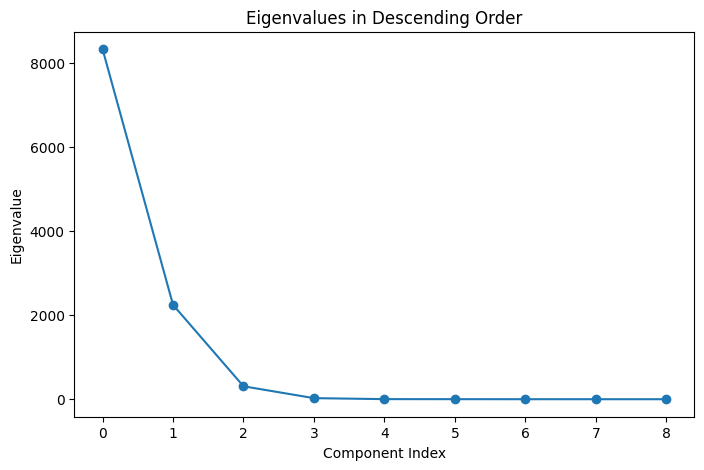

In [44]:

idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[idx]

plt.plot(eigenvalues_sorted, marker='o')
plt.title('Eigenvalues in Descending Order')
plt.xlabel('Component Index')
plt.ylabel('Eigenvalue')
plt.show()

In [48]:

pca = PCA()
X_pca = pca.fit_transform(X)
er = pca.explained_variance_ratio_
print('Eigen values:',pca.explained_variance_)
print('explained variance ratio:', er)
print('Eigen vectors:', pca.components_)
cum_var = np.cumsum(er)
print('Cumulative variance:', cum_var)


Eigen values: [8.33574018e+03 2.24711525e+03 3.08120631e+02 2.55298643e+01
 2.32450816e+00 1.25089191e+00 2.36359139e-01 9.42910034e-03
 6.72606134e-04]
explained variance ratio: [7.63323257e-01 2.05773608e-01 2.82153280e-02 2.33782948e-03
 2.12860658e-04 1.14547103e-04 2.16439601e-05 8.63444809e-07
 6.15921195e-08]
Eigen vectors: [[ 1.10196942e-03 -9.10075631e-01 -5.59934910e-02 -4.03538257e-01
   1.63297871e-02  8.02842901e-05  1.39435382e-05 -9.22335146e-05
   7.42701702e-02]
 [-1.70101516e-04  1.30517870e-01  9.00694579e-01 -3.97112463e-01
   1.46295464e-02  7.37050122e-05  6.46350592e-05  1.42733472e-04
   1.17481789e-01]
 [-6.12099843e-04 -3.89579581e-01  4.18205781e-01  8.20561164e-01
  -2.61476814e-03 -9.50574414e-04 -6.93390453e-04 -1.46579136e-03
   5.52897718e-04]
 [-1.08666532e-03 -5.35825220e-02  1.03219093e-01 -7.77191053e-02
  -6.97345310e-02  4.10913882e-03 -1.33768368e-02 -6.03461926e-02
  -9.85765134e-01]
 [-5.79220122e-04 -4.28219004e-03  6.90445378e-03 -3.87075265e-

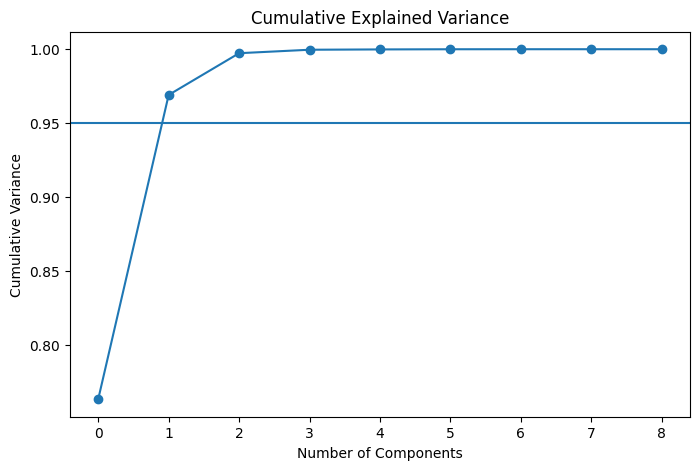

In [49]:
plt.plot(cum_var, marker='o')
plt.axhline(y=0.95)
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.show()

In [71]:
# Retain components with >=95% variance
n_components_95 = np.argmax(cum_var >= 0.95)+1
pca_95 = PCA(n_components=n_components_95)
X_reduced_95 = pca_95.fit_transform(X)

cov_reduced_95 = np.cov(X_reduced_95, rowvar=False)
cov_reduced_95

array([[ 8.33574018e+03, -4.17395222e-13],
       [-4.17395222e-13,  2.24711525e+03]])

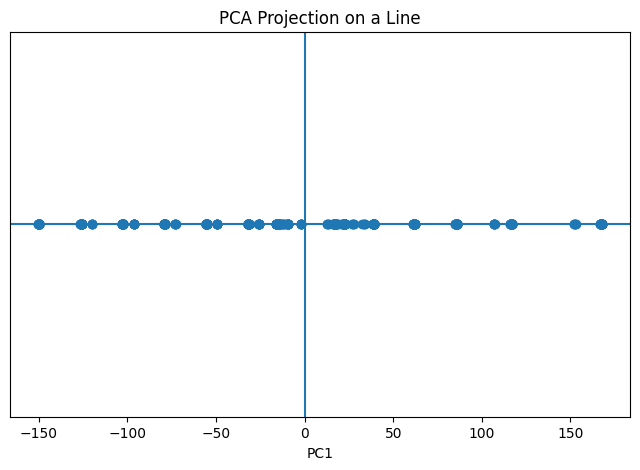

In [72]:
plt.scatter(X_reduced_95[:,0], np.zeros_like(X_reduced_95[:,0]))
plt.axhline(0)
plt.axvline(0)
plt.xlabel("PC1")
plt.yticks([])
plt.title("PCA Projection on a Line")
plt.show()


In [73]:
n_components_95

2

In [61]:
X_reduced_95

array([[ 166.42138587,  -18.11840865],
       [  32.64034834,    1.067792  ],
       [ 166.42154643,  -18.11826124],
       ...,
       [-149.73828996,   42.72747754],
       [-149.73523887,   42.73225052],
       [  13.71790432,   52.75276041]])

In [62]:
pca.explained_variance_

array([8.33574018e+03, 2.24711525e+03, 3.08120631e+02, 2.55298643e+01,
       2.32450816e+00, 1.25089191e+00, 2.36359139e-01, 9.42910034e-03,
       6.72606134e-04])

In [63]:
print('Eigen vectors:', pca.components_)

Eigen vectors: [[ 1.10196942e-03 -9.10075631e-01 -5.59934910e-02 -4.03538257e-01
   1.63297871e-02  8.02842901e-05  1.39435382e-05 -9.22335146e-05
   7.42701702e-02]
 [-1.70101516e-04  1.30517870e-01  9.00694579e-01 -3.97112463e-01
   1.46295464e-02  7.37050122e-05  6.46350592e-05  1.42733472e-04
   1.17481789e-01]
 [-6.12099843e-04 -3.89579581e-01  4.18205781e-01  8.20561164e-01
  -2.61476814e-03 -9.50574414e-04 -6.93390453e-04 -1.46579136e-03
   5.52897718e-04]
 [-1.08666532e-03 -5.35825220e-02  1.03219093e-01 -7.77191053e-02
  -6.97345310e-02  4.10913882e-03 -1.33768368e-02 -6.03461926e-02
  -9.85765134e-01]
 [-5.79220122e-04 -4.28219004e-03  6.90445378e-03 -3.87075265e-03
  -4.80028965e-02  5.55334957e-03  1.05348021e-02  9.97135792e-01
  -5.65047466e-02]
 [ 6.49232236e-04  1.18903528e-04  1.00837367e-04 -1.12056565e-03
   6.22889441e-03 -9.99951827e-01 -9.93835330e-04  5.60059611e-03
  -4.84655925e-03]
 [ 2.74492079e-02  8.09239657e-03 -3.79592225e-03  8.98140547e-03
   9.88460381

In [74]:
df_reduced_95= pd.DataFrame(
    X_reduced_95,
    columns=['c1','c2'],
    index=df_corrected.index
)
df_reduced_95.to_csv("energy_efficiency_pca_all.csv", index=False)

In [75]:
df_reduced_95

,c1,c2
0,166.421386,-18.118409
1,32.640348,1.067792
2,166.421546,-18.118261
3,166.421627,-18.118188
4,115.905297,6.100849
...,...,...
763,-125.962465,17.632090
764,-15.949825,23.553025
765,-149.738290,42.727478
766,-149.735239,42.732251


In [76]:
n_components = len(cum_var)
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X)
cov_reduced = np.cov(X_reduced, rowvar=False)
cov_reduced

array([[ 8.33574018e+03, -1.04348805e-13, -5.21744027e-14,
        -1.89725101e-14,  1.06720369e-14,  2.92739902e-15,
        -4.15023658e-15,  2.96445470e-16,  2.20018122e-16],
       [-1.04348805e-13,  2.24711525e+03,  5.21744027e-14,
        -7.11469128e-15, -1.64897793e-15,  5.55835256e-16,
         4.29845931e-15, -4.63196047e-17,  4.63196047e-18],
       [-5.21744027e-14,  5.21744027e-14,  3.08120631e+02,
        -7.70758222e-15,  1.37106030e-15,  7.41113675e-17,
        -2.96445470e-16, -6.19524713e-17,  6.02154861e-17],
       [-1.89725101e-14, -7.11469128e-15, -7.70758222e-15,
         2.55298643e+01,  5.18779572e-16,  3.10341351e-16,
        -1.85278419e-16, -1.01903130e-16,  2.08438221e-17],
       [ 1.06720369e-14, -1.64897793e-15,  1.37106030e-15,
         5.18779572e-16,  2.32450816e+00, -7.10716434e-17,
         2.31598023e-16, -1.73698518e-18,  4.34246294e-19],
       [ 2.92739902e-15,  5.55835256e-16,  7.41113675e-17,
         3.10341351e-16, -7.10716434e-17,  1.250891

In [77]:
pca.explained_variance_

array([8.33574018e+03, 2.24711525e+03, 3.08120631e+02, 2.55298643e+01,
       2.32450816e+00, 1.25089191e+00, 2.36359139e-01, 9.42910034e-03,
       6.72606134e-04])

In [78]:
pca.components_

array([[ 1.10196942e-03, -9.10075631e-01, -5.59934910e-02,
        -4.03538257e-01,  1.63297871e-02,  8.02842901e-05,
         1.39435382e-05, -9.22335146e-05,  7.42701702e-02],
       [-1.70101516e-04,  1.30517870e-01,  9.00694579e-01,
        -3.97112463e-01,  1.46295464e-02,  7.37050122e-05,
         6.46350592e-05,  1.42733472e-04,  1.17481789e-01],
       [-6.12099843e-04, -3.89579581e-01,  4.18205781e-01,
         8.20561164e-01, -2.61476814e-03, -9.50574414e-04,
        -6.93390453e-04, -1.46579136e-03,  5.52897718e-04],
       [-1.08666532e-03, -5.35825220e-02,  1.03219093e-01,
        -7.77191053e-02, -6.97345310e-02,  4.10913882e-03,
        -1.33768368e-02, -6.03461926e-02, -9.85765134e-01],
       [-5.79220122e-04, -4.28219004e-03,  6.90445378e-03,
        -3.87075265e-03, -4.80028965e-02,  5.55334957e-03,
         1.05348021e-02,  9.97135792e-01, -5.65047466e-02],
       [ 6.49232236e-04,  1.18903528e-04,  1.00837367e-04,
        -1.12056565e-03,  6.22889441e-03, -9.999518

In [80]:
df_reduced= pd.DataFrame(
    X_reduced,
    columns=['c1','c2','c3','c4','c5','c6','c7','c8','c9'],
    index=df_corrected.index
)
df_reduced.to_csv("energy_efficiency_pca_select.csv", index=False)

In [81]:
pca = PCA(n_components=n_components)
pca.fit(X)
pca.components_

array([[ 1.10196942e-03, -9.10075631e-01, -5.59934910e-02,
        -4.03538257e-01,  1.63297871e-02,  8.02842901e-05,
         1.39435382e-05, -9.22335146e-05,  7.42701702e-02],
       [-1.70101516e-04,  1.30517870e-01,  9.00694579e-01,
        -3.97112463e-01,  1.46295464e-02,  7.37050122e-05,
         6.46350592e-05,  1.42733472e-04,  1.17481789e-01],
       [-6.12099843e-04, -3.89579581e-01,  4.18205781e-01,
         8.20561164e-01, -2.61476814e-03, -9.50574414e-04,
        -6.93390453e-04, -1.46579136e-03,  5.52897718e-04],
       [-1.08666532e-03, -5.35825220e-02,  1.03219093e-01,
        -7.77191053e-02, -6.97345310e-02,  4.10913882e-03,
        -1.33768368e-02, -6.03461926e-02, -9.85765134e-01],
       [-5.79220122e-04, -4.28219004e-03,  6.90445378e-03,
        -3.87075265e-03, -4.80028965e-02,  5.55334957e-03,
         1.05348021e-02,  9.97135792e-01, -5.65047466e-02],
       [ 6.49232236e-04,  1.18903528e-04,  1.00837367e-04,
        -1.12056565e-03,  6.22889441e-03, -9.999518

In [82]:
pca.explained_variance_

array([8.33574018e+03, 2.24711525e+03, 3.08120631e+02, 2.55298643e+01,
       2.32450816e+00, 1.25089191e+00, 2.36359139e-01, 9.42910034e-03,
       6.72606134e-04])

In [83]:
X_reduced_transform = pca.transform(X)

In [84]:
X_reduced

array([[ 1.66421386e+02, -1.81184087e+01, -1.51623543e+00, ...,
         4.01994008e-01, -6.50406837e-02,  3.27014320e-02],
       [ 3.26403483e+01,  1.06779200e+00, -5.87853845e+01, ...,
         1.59846530e+00, -7.28146109e-02,  1.07085584e-01],
       [ 1.66421546e+02, -1.81182612e+01, -1.51813658e+00, ...,
         4.15771997e-01, -6.47310852e-02,  3.36432041e-02],
       ...,
       [-1.49738290e+02,  4.27274775e+01,  5.15366817e+00, ...,
         1.40793188e-01, -1.60126540e-01,  2.43479982e-02],
       [-1.49735239e+02,  4.27322505e+01,  5.15273971e+00, ...,
         1.44779355e-01, -1.59109868e-01,  2.48713828e-02],
       [ 1.37179043e+01,  5.27527604e+01,  2.10883048e+00, ...,
        -1.70965856e+00, -9.57600453e-02, -8.74237833e-02]])

In [85]:
X_pca

array([[ 1.66421386e+02, -1.81184087e+01, -1.51623543e+00, ...,
         4.01994008e-01, -6.50406837e-02,  3.27014320e-02],
       [ 3.26403483e+01,  1.06779200e+00, -5.87853845e+01, ...,
         1.59846530e+00, -7.28146109e-02,  1.07085584e-01],
       [ 1.66421546e+02, -1.81182612e+01, -1.51813658e+00, ...,
         4.15771997e-01, -6.47310852e-02,  3.36432041e-02],
       ...,
       [-1.49738290e+02,  4.27274775e+01,  5.15366817e+00, ...,
         1.40793188e-01, -1.60126540e-01,  2.43479982e-02],
       [-1.49735239e+02,  4.27322505e+01,  5.15273971e+00, ...,
         1.44779355e-01, -1.59109868e-01,  2.48713828e-02],
       [ 1.37179043e+01,  5.27527604e+01,  2.10883048e+00, ...,
        -1.70965856e+00, -9.57600453e-02, -8.74237833e-02]])